# This part will be used to webscrape data needed for NLP sentiments
# NLP sentiments will be processed here before it used on the main project

### Extraction Loop

In [14]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd
from concurrent.futures import ThreadPoolExecutor 
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline

ModuleNotFoundError: No module named 'transformers'

In [2]:
def scrape_page(page_num):
    headers = {'User-Agent' : 'Mozilla/5.0'}
    if page_num == 1:
        url = 'https://www.bworldonline.com/banking-finance/'
    else:
        url = f'https://www.bworldonline.com/banking-finance/page/{page_num}/'

    try:
        response = requests.get(url, headers = headers, timeout = 10)
        if response.status_code != 200:
            return [] 

        soup = BeautifulSoup(response.text, 'html.parser')
        containers = soup.find_all('div', class_='td_module_10')

        page_data = []
        for box in containers: 
            headline_tag = box.find('h3').find('a')
            headline = headline_tag.get_text(strip = True)
            link = headline_tag.get('href')
            parts = link.split('/')

            # Format: YYYY-MM-DD
            date_val = f'{parts[4]}-{parts[5]}-{parts[6]}'
            page_data.append({
                'date' : date_val,
                'headline' : headline
            })
        return page_data
    except Exception as e:
        print(f'skipped an article because: {e}')
        return []

# Manager 

pages = range(1,801)
all_headlines = [] 

print('Start Scraping')
start_time = time.time()

with ThreadPoolExecutor(max_workers = 10) as executor:
    results = list(executor.map(scrape_page, pages))

for i in results: 
    all_headlines.extend(i)

end_time = time.time()
print(f'Finished! Scraped {len(all_headlines)} headlines in {round(end_time - start_time, 2)} seconds.')

Start Scraping
Finished! Scraped 9600 headlines in 139.85 seconds.


In [3]:
df = pd.DataFrame(all_headlines)

In [4]:
df_cleaned = df.drop_duplicates(subset = ['headline'], keep='first')

In [5]:
df_cleaned.reset_index(drop = True)
df_cleaned

,date,headline
0,2026-05-07,Term deposit yield ends higher as market sees ...
1,2026-05-07,AIA Philippines eyes sustained profit growth a...
2,2026-05-07,Peso rises on US-Iran deal hopes
3,2026-05-07,PBB net income drops to P221.56M
4,2026-05-06,Bond yields surge on CPI data
...,...,...
9595,2018-11-13,Gov’t fully awards T-bills on steady rates
9596,2018-11-13,BSP eyes 25% exposure limit for banks
9597,2018-11-13,Rediscount loans climb on tighter money supply
9598,2018-11-13,Credit information system up by December


In [6]:
df = df_cleaned[df_cleaned['date'] >= '2021-01-01']

In [7]:
df.to_csv('bworld_master_2021_2026.csv', index = False)

In [8]:
df.tail

<bound method NDFrame.tail of             date                                           headline
0     2026-05-07  Term deposit yield ends higher as market sees ...
1     2026-05-07  AIA Philippines eyes sustained profit growth a...
2     2026-05-07                   Peso rises on US-Iran deal hopes
3     2026-05-07                   PBB net income drops to P221.56M
4     2026-05-06                      Bond yields surge on CPI data
...          ...                                                ...
6711  2021-01-05     LANDBANK’s agricultural loans hit P232 billion
6713  2021-01-04  Rates of T-bills, bonds to move sideways as vi...
6714  2021-01-04         China caps real estate loans to curb risks
6715  2021-01-04           Gov’t debt yields flat on rate cut hints
6716  2021-01-03         Peso to weaken this year as trade recovers

[6555 rows x 2 columns]>

In [9]:
df['date'] = pd.to_datetime(df['date'])

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_10152\3532345252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'])


In [10]:
df['headline_clean'] = df['headline'].str.lower()
df

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_10152\1523151879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['headline_clean'] = df['headline'].str.lower()


,date,headline,headline_clean
0,2026-05-07,Term deposit yield ends higher as market sees ...,term deposit yield ends higher as market sees ...
1,2026-05-07,AIA Philippines eyes sustained profit growth a...,aia philippines eyes sustained profit growth a...
2,2026-05-07,Peso rises on US-Iran deal hopes,peso rises on us-iran deal hopes
3,2026-05-07,PBB net income drops to P221.56M,pbb net income drops to p221.56m
4,2026-05-06,Bond yields surge on CPI data,bond yields surge on cpi data
...,...,...,...
6711,2021-01-05,LANDBANK’s agricultural loans hit P232 billion,landbank’s agricultural loans hit p232 billion
6713,2021-01-04,"Rates of T-bills, bonds to move sideways as vi...","rates of t-bills, bonds to move sideways as vi..."
6714,2021-01-04,China caps real estate loans to curb risks,china caps real estate loans to curb risks
6715,2021-01-04,Gov’t debt yields flat on rate cut hints,gov’t debt yields flat on rate cut hints


In [11]:
def clean_finance_text(text):
    text = text.lower()
    
    text = re.sub(r'(?<!\d)[.,!:?](?!\d) | [^\w\s.]', '', text)
    return text

df['headline_clean'] = df['headline'].apply(clean_finance_text)
df

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_10152\4015545682.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['headline_clean'] = df['headline'].apply(clean_finance_text)


,date,headline,headline_clean
0,2026-05-07,Term deposit yield ends higher as market sees ...,term deposit yield ends higher as market sees ...
1,2026-05-07,AIA Philippines eyes sustained profit growth a...,aia philippines eyes sustained profit growth a...
2,2026-05-07,Peso rises on US-Iran deal hopes,peso rises on us-iran deal hopes
3,2026-05-07,PBB net income drops to P221.56M,pbb net income drops to p221.56m
4,2026-05-06,Bond yields surge on CPI data,bond yields surge on cpi data
...,...,...,...
6711,2021-01-05,LANDBANK’s agricultural loans hit P232 billion,landbank’s agricultural loans hit p232 billion
6713,2021-01-04,"Rates of T-bills, bonds to move sideways as vi...",rates of t-billsbonds to move sideways as viru...
6714,2021-01-04,China caps real estate loans to curb risks,china caps real estate loans to curb risks
6715,2021-01-04,Gov’t debt yields flat on rate cut hints,gov’t debt yields flat on rate cut hints


In [12]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return ' '.join(filtered_words)

df['headline_final'] = df['headline_clean'].apply(remove_stopwords)
df[['headline_clean', 'headline_final']]

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_10152\3118024351.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['headline_final'] = df['headline_clean'].apply(remove_stopwords)


,headline_clean,headline_final
0,term deposit yield ends higher as market sees ...,term deposit yield ends higher market sees bsp...
1,aia philippines eyes sustained profit growth a...,aia philippines eyes sustained profit growth a...
2,peso rises on us-iran deal hopes,peso rises us-iran deal hopes
3,pbb net income drops to p221.56m,pbb net income drops p221.56m
4,bond yields surge on cpi data,bond yields surge cpi data
...,...,...
6711,landbank’s agricultural loans hit p232 billion,landbank’s agricultural loans hit p232 billion
6713,rates of t-billsbonds to move sideways as viru...,rates t-billsbonds move sideways virus fears p...
6714,china caps real estate loans to curb risks,china caps real estate loans curb risks
6715,gov’t debt yields flat on rate cut hints,gov’t debt yields flat rate cut hints


In [13]:
sample_idx = 10
original = df.iloc[sample_idx]['headline']
cleaned = df.iloc[sample_idx]['headline_final']

print(f'ORIGINAL : {original}')
print(f'CLEANED : {cleaned}')
print(f'--- Saved {len(original.split()) - len(cleaned.split())} useless words --')

ORIGINAL : BTr partially awards T-bills as yields jump on inflation woes
CLEANED : btr partially awards t-bills yields jump inflation woes
--- Saved 2 useless words --


In [14]:
df_cleaned = df.reset_index(drop=True)
df_cleaned

,date,headline,headline_clean,headline_final
0,2026-05-07,Term deposit yield ends higher as market sees ...,term deposit yield ends higher as market sees ...,term deposit yield ends higher market sees bsp...
1,2026-05-07,AIA Philippines eyes sustained profit growth a...,aia philippines eyes sustained profit growth a...,aia philippines eyes sustained profit growth a...
2,2026-05-07,Peso rises on US-Iran deal hopes,peso rises on us-iran deal hopes,peso rises us-iran deal hopes
3,2026-05-07,PBB net income drops to P221.56M,pbb net income drops to p221.56m,pbb net income drops p221.56m
4,2026-05-06,Bond yields surge on CPI data,bond yields surge on cpi data,bond yields surge cpi data
...,...,...,...,...
6550,2021-01-05,LANDBANK’s agricultural loans hit P232 billion,landbank’s agricultural loans hit p232 billion,landbank’s agricultural loans hit p232 billion
6551,2021-01-04,"Rates of T-bills, bonds to move sideways as vi...",rates of t-billsbonds to move sideways as viru...,rates t-billsbonds move sideways virus fears p...
6552,2021-01-04,China caps real estate loans to curb risks,china caps real estate loans to curb risks,china caps real estate loans curb risks
6553,2021-01-04,Gov’t debt yields flat on rate cut hints,gov’t debt yields flat on rate cut hints,gov’t debt yields flat rate cut hints


In [15]:
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer() 

df['sentiment_score'] = df['headline_final'].apply(lambda x: sia.polarity_scores(x)['compound'])

print(df[['headline','sentiment_score']].head())

[nltk_data] Downloading package vader_lexicon to C:\Users\Marry Bless
[nltk_data]     Magat\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                            headline  sentiment_score
0  Term deposit yield ends higher as market sees ...           0.0000
1  AIA Philippines eyes sustained profit growth a...           0.6705
2                   Peso rises on US-Iran deal hopes           0.4215
3                   PBB net income drops to P221.56M           0.0000
4                      Bond yields surge on CPI data           0.0000


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_28608\2721451159.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_score'] = df['headline_final'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [43]:
df[df['sentiment_score'].isna()].count()

date               0
headline           0
headline_clean     0
headline_final     0
sentiment_score    0
dtype: int64

In [21]:
df_inf = pd.read_excel('Inflation rates from upto march.xlsx')

In [33]:
df_monthly = df[['sentiment_score']].resample('M').mean()

df_monthly = df_monthly.reset_index()

df_monthly.to_csv('monthly_sentiment.csv', index = False)

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [94]:
df_resamp = df[['headline']].resample('M').count()
df_resamp.reset_index(inplace = True)


In [105]:
df_resamp['date'] = pd.to_datetime(df_resamp['date'].dt.to_period('M').dt.to_timestamp())
df_monthly['date'] = pd.to_datetime(df_monthly['date'].dt.to_period('M').dt.to_timestamp())

pd.merge(df_resamp, df_monthly, on = 'date', how = 'inner')['headline'].min()

20

In [45]:
df[df['sentiment_score'].isna()].count()

date               0
headline           0
headline_clean     0
headline_final     0
sentiment_score    0
dtype: int64

In [31]:
df_daily = df[['sentiment_score']].resample('D').count()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [34]:
df_indexed = df.set_index(df['date'], drop= True)

In [36]:
df_daily = df_indexed[['sentiment_score']].resample('D').mean()

In [56]:
df_daily_agg_dropped = df_daily.dropna(subset = ['sentiment_score'])

In [65]:
df_daily_dropped = df[df['sentiment_score']  != 0].copy()

In [68]:
df_daily_dropped_filtered = df_daily_dropped.groupby('date')['sentiment_score'].mean().reset_index()
df_daily_dropped_filtered

,date,sentiment_score
0,2021-01-03,-0.421500
1,2021-01-04,-0.417367
2,2021-01-05,0.192533
3,2021-01-06,0.317550
4,2021-01-07,-0.376450
...,...,...
1407,2026-05-01,-0.021000
1408,2026-05-04,-0.328960
1409,2026-05-05,-0.339267
1410,2026-05-06,0.378367


In [117]:
df_daily_dropped = df_daily_dropped.set_index('date')

In [119]:
df_daily_dropped_resamp = df_daily_dropped[['sentiment_score']].resample('D').mean()

In [145]:
df_daily_dropped_resamp

,sentiment_score
date,
2021-01-03,-0.421500
2021-01-04,-0.417367
2021-01-05,0.192533
2021-01-06,0.317550
2021-01-07,-0.376450
...,...
2026-05-03,NaN
2026-05-04,-0.328960
2026-05-05,-0.339267


In [147]:
df_daily_dropped_filtered_resamp['rolling_avg'] = df_daily_dropped_resamp['sentiment_score'].rolling(window = 30, center = True, min_periods =1).mean()

In [148]:
df_resamppp = df_daily_dropped_filtered_resamp.reset_index()

In [149]:
df_resamppp

,date,sentiment_score,rolling_avg
0,2021-01-03,-0.421500,0.029450
1,2021-01-04,-0.417367,-0.010742
2,2021-01-05,0.192533,-0.005188
3,2021-01-06,0.317550,0.038398
4,2021-01-07,-0.376450,0.060458
...,...,...,...
1946,2026-05-03,-0.021000,0.161521
1947,2026-05-04,-0.328960,0.161521
1948,2026-05-05,-0.339267,0.161521
1949,2026-05-06,0.378367,0.159196


In [123]:
df_daily_dropped_resamp = df_daily_dropped[['sentiment_score']].resample('D').mean()

In [22]:
df_inf['rolling_avg'] = df_inf['inflation'].rolling(window = 3, center = True).mean()

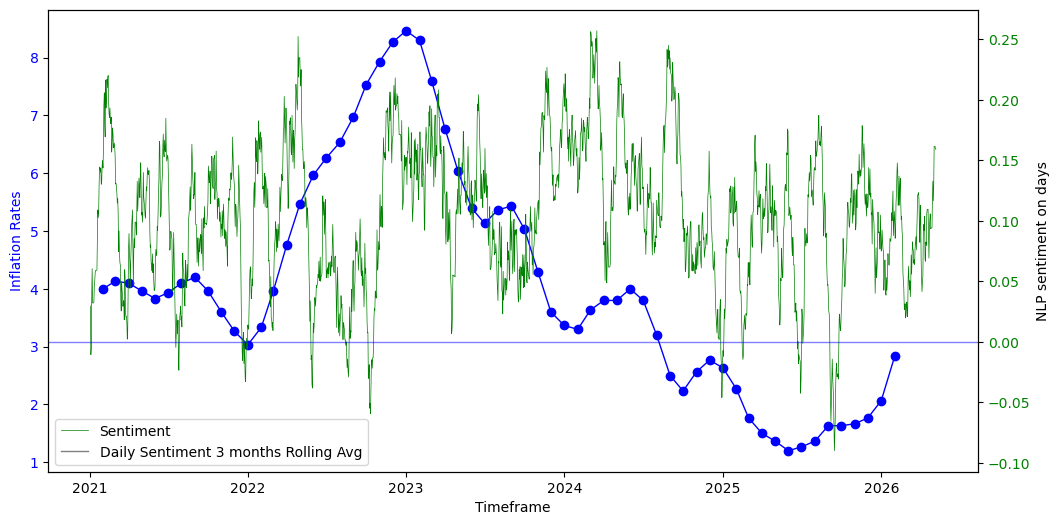

In [151]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.set_xlabel('Timeframe')
ax1.set_ylabel('Inflation Rates', color = 'b')
ax1.plot(df_inf['month'], df_inf['rolling_avg'], color = 'b',marker = 'o', linewidth = 1, label = 'Inflation Rate')
ax1.tick_params(axis = 'y', labelcolor = 'b')

ax2 = ax1.twinx()

ax2.set_ylabel('NLP sentiment on days')
ax2.plot(df_resamppp['date'], df_resamppp['rolling_avg'], color = 'g', linewidth = 0.5, label = 'Sentiment')
ax2.tick_params(axis = 'y', labelcolor = 'g')

plt.axhline(0, color = 'b', linewidth =1, alpha = 0.5)
plt.axhline(df_daily['rolling_avg'].mean(), color = 'black', linewidth = 1, alpha = 0.5, label = 'Daily Sentiment 3 months Rolling Avg')
plt.legend()
plt.show()

In [155]:
print(f"Same Month: {df_inf['inflation'].corr(df_resamppp['rolling_avg']):.4f}")
print(f"1 Month Lag: {df_inf['inflation'].corr(df_resamppp['rolling_avg'].shift(1)):.4f}")
print(f"2 Month Lag: {df_inf['inflation'].corr(df_resamppp['rolling_avg'].shift(2)):.4f}")

Same Month: -0.1091
1 Month Lag: -0.1640
2 Month Lag: -0.2191


In [153]:
df_resamppp['inflation'] = df_inf['inflation']
df_resamppp

,date,sentiment_score,rolling_avg,inflation
0,2021-01-03,-0.421500,0.029450,3.7
1,2021-01-04,-0.417367,-0.010742,4.2
2,2021-01-05,0.192533,-0.005188,4.1
3,2021-01-06,0.317550,0.038398,4.1
4,2021-01-07,-0.376450,0.060458,4.1
...,...,...,...,...
1946,2026-05-03,-0.021000,0.161521,NaN
1947,2026-05-04,-0.328960,0.161521,NaN
1948,2026-05-05,-0.339267,0.161521,NaN
1949,2026-05-06,0.378367,0.159196,NaN


In [154]:
from statsmodels.tsa.stattools import grangercausalitytests
df_diff = df_resamppp[['inflation', 'sentiment_score']].diff().dropna()

gc_diff = grangercausalitytests(df_diff[['inflation', 'sentiment_score']], maxlag = 3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3672  , p=0.5469  , df_denom=58, df_num=1
ssr based chi2 test:   chi2=0.3862  , p=0.5343  , df=1
likelihood ratio test: chi2=0.3850  , p=0.5350  , df=1
parameter F test:         F=0.3672  , p=0.5469  , df_denom=58, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3115  , p=0.7336  , df_denom=55, df_num=2
ssr based chi2 test:   chi2=0.6797  , p=0.7119  , df=2
likelihood ratio test: chi2=0.6759  , p=0.7132  , df=2
parameter F test:         F=0.3115  , p=0.7336  , df_denom=55, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7344  , p=0.5362  , df_denom=52, df_num=3
ssr based chi2 test:   chi2=2.4999  , p=0.4753  , df=3
likelihood ratio test: chi2=2.4484  , p=0.4847  , df=3
parameter F test:         F=0.7344  , p=0.5362  , df_denom=52, df_num=3


In [161]:
df_non_zero = df[df['sentiment_score'] != 0].copy().set_index('date')

In [170]:
df_monthly = df_non_zero[['sentiment_score']].resample('M').mean().reset_index()

In [175]:
df_monthly['date'] = pd.to_datetime(df_monthly['date']).dt.to_period('M').dt.to_timestamp()
df_inf['month'] = pd.to_datetime(df_inf['month']).dt.to_period('M').dt.to_timestamp()

In [176]:
df_monthly['inflation'] = df_inf['inflation']

In [179]:
df_monthly

,date,sentiment_score,inflation
0,2021-01-01,0.056538,3.7
1,2021-02-01,0.193864,4.2
2,2021-03-01,0.077868,4.1
3,2021-04-01,0.129935,4.1
4,2021-05-01,0.156313,4.1
...,...,...,...
60,2026-01-01,0.073811,2.0
61,2026-02-01,0.098545,2.4
62,2026-03-01,0.035587,4.1
63,2026-04-01,0.064500,NaN


In [178]:
print(f"Same Month: {df_monthly['inflation'].corr(df_monthly['sentiment_score']):.4f}")
print(f"1 Month Lag: {df_monthly['inflation'].corr(df_monthly['sentiment_score'].shift(1)):.4f}")
print(f"2 Month Lag: {df_monthly['inflation'].corr(df_monthly['sentiment_score'].shift(2)):.4f}")

Same Month: 0.0967
1 Month Lag: 0.0363
2 Month Lag: 0.0241
